In [14]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [15]:
from google.colab import files
uploaded= files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 64 bytes


In [16]:
!kaggle datasets download -d dqmonn/zalando-store-crawl

Dataset URL: https://www.kaggle.com/datasets/dqmonn/zalando-store-crawl
License(s): copyright-authors
zalando-store-crawl.zip: Skipping, found more recently modified local copy (use --force to force download)


In [17]:
!unzip zalando-store-crawl.zip

Archive:  zalando-store-crawl.zip
replace zalando/hoodies-female/0VB21J000-Q11@7.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [18]:
data_dir = '/content/zalando'

In [19]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('/content/zalando')

In [20]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('/content/zalando/longsleeve/MQ122O00J-A11@8.jpg'),
 PosixPath('/content/zalando/longsleeve/HT622O009-K11@10.jpg'),
 PosixPath('/content/zalando/longsleeve/VA222O05M-Q11@8.jpg'),
 PosixPath('/content/zalando/longsleeve/YO122O0FU-A11@12.1.jpg'),
 PosixPath('/content/zalando/longsleeve/PE122O065-K11@12.jpg')]

In [21]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

16175


In [22]:
longsleeve = list(data_dir.glob('longsleeve/*'))
longsleeve[:5]

[PosixPath('/content/zalando/longsleeve/MQ122O00J-A11@8.jpg'),
 PosixPath('/content/zalando/longsleeve/HT622O009-K11@10.jpg'),
 PosixPath('/content/zalando/longsleeve/VA222O05M-Q11@8.jpg'),
 PosixPath('/content/zalando/longsleeve/YO122O0FU-A11@12.1.jpg'),
 PosixPath('/content/zalando/longsleeve/PE122O065-K11@12.jpg')]

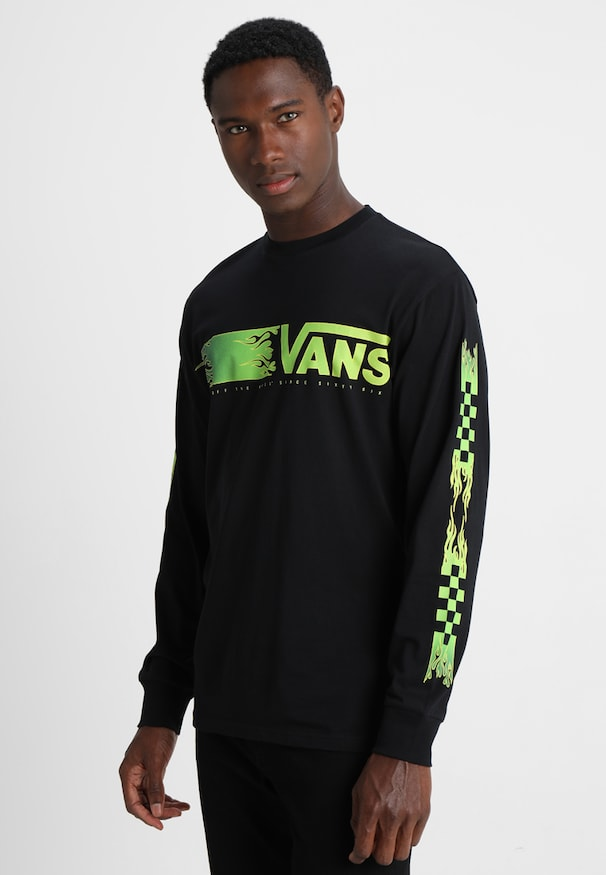

In [23]:
PIL.Image.open(str(longsleeve[2]))

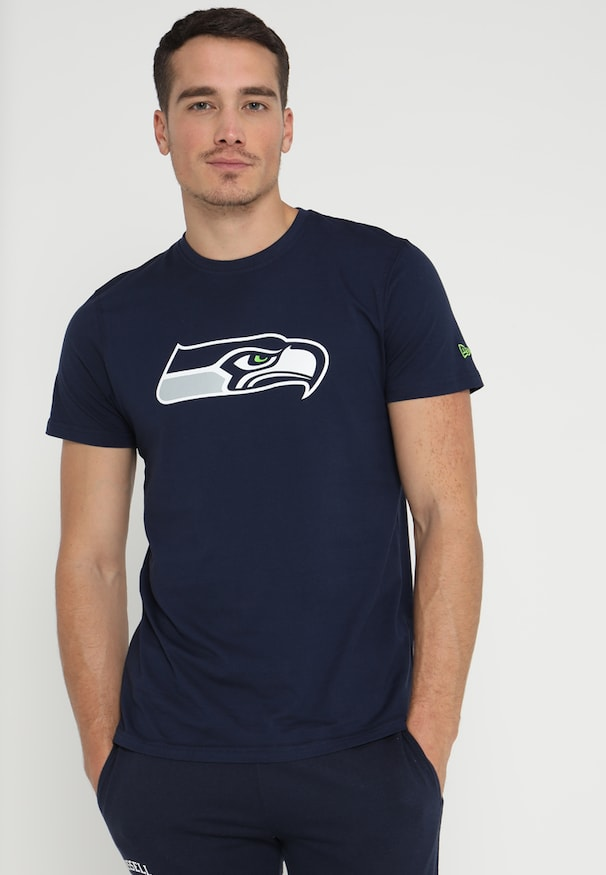

In [24]:
shirt = list(data_dir.glob('shirt/*'))
PIL.Image.open(str(shirt[2]))

In [25]:
for subdir in data_dir.iterdir():
    if subdir.is_dir():
        for txt_file in subdir.glob('*.txt'):
            try:
                txt_file.unlink()
                print(f"Deleted {txt_file}")
            except Exception as e:
                print(f"Error deleting {txt_file}: {e}")

Deleted /content/zalando/longsleeve/longsleeve.txt
Deleted /content/zalando/sweatshirt-female/sweatshirtwomen.txt
Deleted /content/zalando/hoodies-female/hoodieswomen.txt
Deleted /content/zalando/sweatshirt/sweatshirt.txt
Deleted /content/zalando/hoodies/hoodies.txt
Deleted /content/zalando/shirt/shirt.txt


In [26]:
clothes_images_dict = {
    'hoodies': list(data_dir.glob('hoodies/*')),
    'hoodies-female': list(data_dir.glob('hoodies-female/*')),
    'longsleeve': list(data_dir.glob('longsleeve/*')),
    'shirt': list(data_dir.glob('shirt/*')),
    'sweatshirt': list(data_dir.glob('sweatshirt/*')),
}

In [27]:
clothes_labels_dict = {
    'hoodies': 0,
    'hoodies-female': 1,
    'longsleeve': 2,
    'shirt': 3,
    'sweatshirt': 4,
}

In [28]:
clothes_images_dict['longsleeve'][:5]

[PosixPath('/content/zalando/longsleeve/MQ122O00J-A11@8.jpg'),
 PosixPath('/content/zalando/longsleeve/HT622O009-K11@10.jpg'),
 PosixPath('/content/zalando/longsleeve/VA222O05M-Q11@8.jpg'),
 PosixPath('/content/zalando/longsleeve/YO122O0FU-A11@12.1.jpg'),
 PosixPath('/content/zalando/longsleeve/PE122O065-K11@12.jpg')]

In [29]:
img = cv2.imread(str(clothes_images_dict['longsleeve'][1].resolve()))
img.shape

(875, 606, 3)

In [30]:
cv2.resize(img, (128, 128)).shape

(128, 128, 3)

In [31]:
X, y = [], []

for clothes_name, images in clothes_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        if img is None:
            print(f"Failed to load image: {image}")
            continue
        resized_img = cv2.resize(img, (128, 128))
        X.append(resized_img)
        y.append(clothes_labels_dict[clothes_name])


In [32]:
X = np.array(X)
y = np.array(y)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
del X, y
import gc
gc.collect()

0

In [34]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

In [35]:
num_classes = 5

model = Sequential([
  layers.RandomZoom(0.1),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(256, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dense(num_classes)
])

In [36]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=10)

Epoch 1/10
322/322 [==============================] - 21s 61ms/step - loss: 1.0704 - accuracy: 0.5444
Epoch 2/10
322/322 [==============================] - 19s 60ms/step - loss: 0.8172 - accuracy: 0.6408
Epoch 3/10
322/322 [==============================] - 19s 60ms/step - loss: 0.7205 - accuracy: 0.6707
Epoch 4/10
322/322 [==============================] - 18s 57ms/step - loss: 0.6455 - accuracy: 0.6953
Epoch 5/10
322/322 [==============================] - 18s 56ms/step - loss: 0.6046 - accuracy: 0.7070
Epoch 6/10
322/322 [==============================] - 18s 54ms/step - loss: 0.5702 - accuracy: 0.7242
Epoch 7/10
322/322 [==============================] - 18s 56ms/step - loss: 0.5457 - accuracy: 0.7262
Epoch 8/10
322/322 [==============================] - 18s 55ms/step - loss: 0.5260 - accuracy: 0.7353
Epoch 9/10
322/322 [==============================] - 18s 57ms/step - loss: 0.4891 - accuracy: 0.7479
Epoch 10/10
322/322 [==============================] - 18s 55ms/step - loss: 0.469

In [37]:
model.evaluate(X_test_scaled,y_test)

108/108 [==============================] - 2s 16ms/step - loss: 0.5369 - accuracy: 0.7217


[0.5369372963905334, 0.7217366099357605]

In [40]:
def predict_image(image):
    img = np.expand_dims(image, axis=0)
    predictions = model.predict(img)
    score = tf.nn.softmax(predictions[0])
    predicted_class = np.argmax(score)
    return predicted_class, score

1/1 [==============================] - 0s 26ms/step
Predicted class: 2


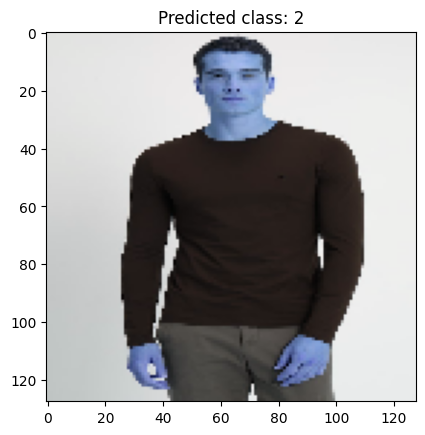

In [45]:
test_image = X_test[1]
predicted_class, score = predict_image(test_image)

print(f"Predicted class: {predicted_class}")

plt.imshow(test_image)
plt.title(f"Predicted class: {predicted_class}")
plt.show()

1/1 [==============================] - 0s 25ms/step
Predicted class: 3


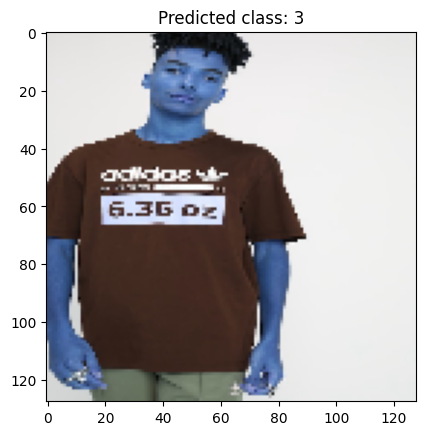

In [46]:
test_image = X_test[8]
predicted_class, score = predict_image(test_image)

print(f"Predicted class: {predicted_class}")

plt.imshow(test_image)
plt.title(f"Predicted class: {predicted_class}")
plt.show()